# Random Forest Model for Predicting 'seen'

In [89]:
# Re-import libraries after code execution environment reset
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the uploaded file
data = pd.read_csv(r'/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/notebooks/observationEventForecasting/DataPreprocessing/FullIndicatorMatrix.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['indicator', 'date']).reset_index(drop=True)
data.ffill(inplace=True)

# Reapply feature engineering
data['days_since_last_seen'] = np.nan
for indicator, group in data.groupby('indicator'):
    seen_dates = group[group['seen'] == 1]['date']
    data.loc[group.index, 'days_since_last_seen'] = group['date'].apply(
        lambda x: (x - seen_dates[seen_dates < x].max()).days if not seen_dates[seen_dates < x].empty else np.nan
    )
data['days_since_last_seen'] = data['days_since_last_seen'].fillna(0).astype(int)

data['ewm_seen'] = data.groupby('indicator')['seen'].apply(lambda x: x.ewm(span=3, adjust=False).mean()).reset_index(drop=True)
data['seen_count_last_3'] = data.groupby('indicator')['seen'].apply(lambda x: x.rolling(window=3, min_periods=1).sum()).reset_index(drop=True)
data['rolling_mean_7'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
data['rolling_mean_14'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=14, min_periods=1).mean())
data['rolling_mean_30'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
data['ewm_seen_long'] = data.groupby('indicator')['seen'].transform(lambda x: x.ewm(span=10, adjust=False).mean())
data['total_seen_last_7'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(7, min_periods=1).sum())
data['total_days_not_seen_last_7'] = data.groupby('indicator')['seen'].transform(lambda x: 7 - x.rolling(7, min_periods=1).sum())
data['activity_score'] = data.groupby('indicator')['seen'].transform('sum')
data['activity_score_normalized'] = (data['activity_score'] - data['activity_score'].min()) / (data['activity_score'].max() - data['activity_score'].min())
data['dayofweek'] = data['date'].dt.dayofweek
data['is_weekend'] = data['dayofweek'].isin([5, 6]).astype(int)

# Feature list
features = [
    'days_since_last_seen', 'ewm_seen', 'seen_count_last_3',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'ewm_seen_long', 'total_seen_last_7', 'total_days_not_seen_last_7',
    'activity_score_normalized', 'dayofweek', 'is_weekend'
]

# Clean and scale
data = data.dropna(subset=features + ['seen'])
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Prepare data for 90-day history to predict 7 days ahead
history_window = 90
forecast_offset = 7
X_90day, y_7day, indicator_ids = [], [], []

from datetime import datetime

# Set expected "today" date
today = pd.to_datetime("2025-04-29")

X_90day, y_7day, indicator_ids = [], [], []

for indicator in data['indicator'].unique():
    group = data[data['indicator'] == indicator].sort_values('date').reset_index(drop=True)

    # Ensure last date in group is "today"
    if group['date'].iloc[-1] != today:
        continue  # skip this indicator — not aligned with today

    # Safe to use fixed index math now
    end_idx = len(group) - forecast_offset  # 7 days before today
    X_window = group.iloc[end_idx - history_window:end_idx][features].values
    y_target = group.iloc[-1]['seen']  # seen value on "today"

    if X_window.shape[0] == history_window:
        X_90day.append(X_window.mean(axis=0))
        y_7day.append(y_target)
        indicator_ids.append(indicator)


# Train and evaluate model
X_90day = np.array(X_90day)
y_7day = np.array(y_7day)

model = RandomForestClassifier(class_weight={0: 1, 1: 3}, random_state=42)
model.fit(X_90day, y_7day)

# Predict probabilities instead of classes
y_probs = model.predict_proba(X_90day)[:, 1]  # Probability of class "1" (seen)

# Apply custom threshold to increase recall (reduce false negatives)
threshold = 0.35
y_pred = (y_probs > threshold).astype(int)

# Generate evaluation metrics
report = classification_report(y_7day, y_pred, output_dict=True)
matrix = confusion_matrix(y_7day, y_pred)




In [91]:
# Generate evaluation metrics
classification_report_dict = classification_report(y_7day, y_pred, output_dict=True)
confusion_matrix_array = confusion_matrix(y_7day, y_pred)

# Build summary dictionary from classification report
evaluation_summary = {
    "Precision": classification_report_dict['1']['precision'],
    "Recall": classification_report_dict['1']['recall'],
    "F1-Score": classification_report_dict['1']['f1-score'],
    "Accuracy": classification_report_dict['accuracy'],
    "Confusion Matrix": confusion_matrix_array.tolist(),
    "Sample Size": len(y_7day)
}
# Convert evaluation summary to a DataFrame
evaluation_summary_df = pd.DataFrame.from_dict(evaluation_summary, orient='index', columns=['Value'])
evaluation_summary_df


,Value
Precision,0.884211
Recall,1.0
F1-Score,0.938547
Accuracy,0.980769
Confusion Matrix,"[[477, 11], [0, 84]]"
Sample Size,572


=== Per-Indicator Results ===
         Indicator  Actual Seen  Predicted Seen
0   102.165.16.161            0               0
1    102.68.39.251            0               0
2   103.140.63.154            0               1
3  103.149.249.226            0               0
4   103.216.220.19            0               1


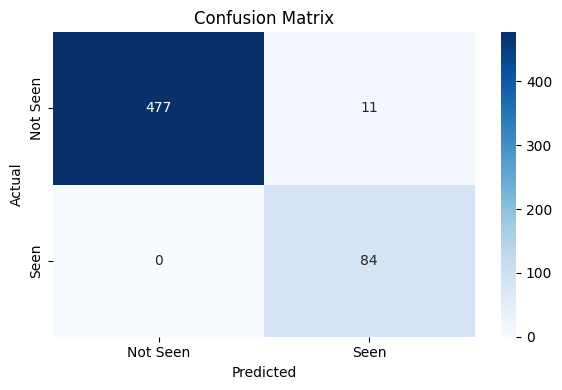

In [92]:
# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Indicator": indicator_ids,
    "Actual Seen": y_7day,
    "Predicted Seen": y_pred
})
print("=== Per-Indicator Results ===")
print(results_df.head())

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Seen', 'Seen'], yticklabels=['Not Seen', 'Seen'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [93]:
true_positives = results_df[(results_df['Actual Seen'] == 1) & (results_df['Predicted Seen'] == 1)]
false_positives = results_df[(results_df['Actual Seen'] == 0) & (results_df['Predicted Seen'] == 1)]
total_positives = results_df[results_df['Actual Seen'] == 1]

percentage = len(true_positives) / (len(true_positives) + len(false_positives)) if (len(true_positives) + len(false_positives)) > 0 else 0
percentage = round(percentage * 100, 2)
print(f"Percentage of true positives among predicted positives: {percentage}%")

Percentage of true positives among predicted positives: 88.42%


In [94]:
print(f"Ratio of true positives to false positives: {len(true_positives)} / {len(total_positives)}")

Ratio of true positives to false positives: 84 / 84


In [95]:
true_positives

,Indicator,Actual Seen,Predicted Seen
10,104.18.69.40,1,1
11,104.192.3.74,1,1
14,104.21.48.1,1,1
26,107.189.3.148,1,1
27,107.189.3.94,1,1
...,...,...,...
496,api-docs.deepseek.com,1,1
508,chat.deepseek.com,1,1
550,status.deepseek.com,1,1
558,www.deepseek.com,1,1


In [96]:
from sklearn.model_selection import train_test_split

# Split indicators
train_inds, test_inds = train_test_split(indicator_ids, test_size=0.2, random_state=42)

# Create train/test datasets
X_train = np.array([x for x, i in zip(X_90day, indicator_ids) if i in train_inds])
y_train = np.array([y for y, i in zip(y_7day, indicator_ids) if i in train_inds])

X_test = np.array([x for x, i in zip(X_90day, indicator_ids) if i in test_inds])
y_test = np.array([y for y, i in zip(y_7day, indicator_ids) if i in test_inds])

# Train
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate separately
print("=== Training Results ===")
print(classification_report(y_train, y_train_pred))

print("=== Testing Results ===")
print(classification_report(y_test, y_test_pred))


=== Training Results ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       393
           1       0.94      1.00      0.97        64

    accuracy                           0.99       457
   macro avg       0.97      0.99      0.98       457
weighted avg       0.99      0.99      0.99       457

=== Testing Results ===
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        95
           1       0.73      0.80      0.76        20

    accuracy                           0.91       115
   macro avg       0.84      0.87      0.85       115
weighted avg       0.92      0.91      0.91       115

